In [2]:
import pandas as pd
df = pd.read_csv("../data/raw/upi_transactions_2024.csv")
print(df.shape)
print(df.head())
print(df.dtypes)

(250000, 17)
  transaction id            timestamp transaction type merchant_category  \
0  TXN0000000001  2024-10-08 15:17:28              P2P     Entertainment   
1  TXN0000000002  2024-04-11 06:56:00              P2M           Grocery   
2  TXN0000000003  2024-04-02 13:27:18              P2P           Grocery   
3  TXN0000000004  2024-01-07 10:09:17              P2P              Fuel   
4  TXN0000000005  2024-01-23 19:04:23              P2P          Shopping   

   amount (INR) transaction_status sender_age_group receiver_age_group  \
0           868            SUCCESS            26-35              18-25   
1          1011            SUCCESS            26-35              26-35   
2           477            SUCCESS            26-35              36-45   
3          2784            SUCCESS            26-35              26-35   
4           990            SUCCESS            26-35              18-25   

    sender_state sender_bank receiver_bank device_type network_type  \
0          Del

In [3]:
# naming consistency

df = df.rename(columns={
    "transaction id": "transaction_id",
    "amount (INR)": "amount_inr"
})
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print(df.columns.tolist())

['transaction_id', 'timestamp', 'transaction_type', 'merchant_category', 'amount_inr', 'transaction_status', 'sender_age_group', 'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank', 'device_type', 'network_type', 'fraud_flag', 'hour_of_day', 'day_of_week', 'is_weekend']


In [4]:
# checking for duplicates
print("Duplicate transaction_ids:", df['transaction_id'].duplicated().sum())
print("Fully duplicate rows:", df.duplicated().sum())

Duplicate transaction_ids: 0
Fully duplicate rows: 0


In [5]:
# parsing timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])
print(df['timestamp'].min(), df['timestamp'].max())
print(df['timestamp'].isna().sum())

2024-01-01 00:05:10 2024-12-30 23:55:40
0


In [7]:
# calculating day_of_week, hour_calc and comparing with source of truth

check = pd.DataFrame({
    'day_of_week_calc': df['timestamp'].dt.day_name(),
    'day_of_week_given': df['day_of_week'],
    'hour_calc': df['timestamp'].dt.hour,
    'hour_given': df['hour_of_day'],
})
mismatches = check[check['day_of_week_calc'] != check['day_of_week_given']]
print(f"Day-of-week mismatches: {len(mismatches)} / {len(df)}")

Day-of-week mismatches: 0 / 250000


In [8]:
# validate categorical values against expected sets

print(df['transaction_status'].unique())
print(df['transaction_type'].unique())
print(df['sender_state'].unique())
print(df['device_type'].unique())
print(df['network_type'].unique())

['SUCCESS' 'FAILED']
['P2P' 'P2M' 'Bill Payment' 'Recharge']
['Delhi' 'Uttar Pradesh' 'Karnataka' 'Telangana' 'Maharashtra' 'Gujarat'
 'Rajasthan' 'Tamil Nadu' 'West Bengal' 'Andhra Pradesh']
['Android' 'iOS' 'Web']
['4G' '5G' 'WiFi' '3G']


In [9]:
# missing values column wise

print(df.isna().sum())

transaction_id        0
timestamp             0
transaction_type      0
merchant_category     0
amount_inr            0
transaction_status    0
sender_age_group      0
receiver_age_group    0
sender_state          0
sender_bank           0
receiver_bank         0
device_type           0
network_type          0
fraud_flag            0
hour_of_day           0
day_of_week           0
is_weekend            0
dtype: int64


count    250000.000000
mean       1311.756036
std        1848.059224
min          10.000000
25%         288.000000
50%         629.000000
75%        1596.000000
max       42099.000000
Name: amount_inr, dtype: float64
0.010       48.000
0.250      288.000
0.500      629.000
0.750     1596.000
0.950     4687.050
0.990     9003.010
0.999    16698.016
Name: amount_inr, dtype: float64


<Axes: >

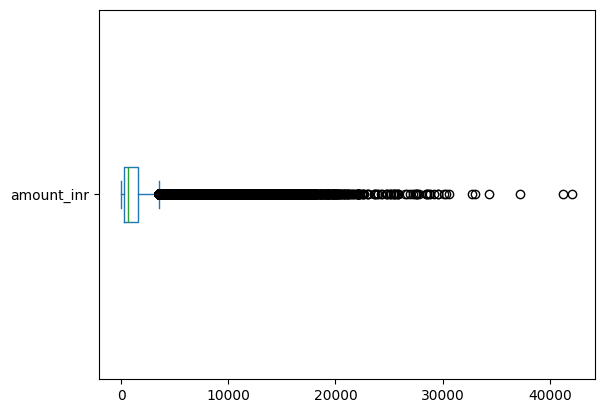

In [10]:
# outliers in amount_inr

print(df['amount_inr'].describe())
print(df['amount_inr'].quantile([0.01, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999]))

# Visual check
df['amount_inr'].plot(kind='box', vert=False)

In [11]:
print(df.groupby('fraud_flag')['amount_inr'].describe())

               count         mean          std   min    25%    50%     75%  \
fraud_flag                                                                   
0           249520.0  1311.395391  1847.210565  10.0  288.0  629.0  1596.0   
1              480.0  1499.231250  2240.707939  28.0  260.0  618.5  1673.5   

                max  
fraud_flag           
0           42099.0  
1           17718.0  


In [12]:
print(pd.crosstab(df['fraud_flag'], df['transaction_status']))

transaction_status  FAILED  SUCCESS
fraud_flag                         
0                    12355   237165
1                       21      459
